# 📖 Lightweight Data Catalog

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-quality-governance/data-catalog/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-quality-governance/data-catalog/demo.ipynb)

> Nobody knows what tables and columns exist, what they mean, or who owns them - so every analysis starts by pinging three people on Slack.

This notebook is **self-contained** (it duplicates the core logic so it runs anywhere with just pandas/numpy/matplotlib - no local imports).

## Contents
1. [Setup](#setup)
2. [Core logic - profile + catalog](#core)
3. [Build the sample tables](#sample)
4. [Profile them into a catalog](#profile)
5. [Inspect one catalog entry](#entry)
6. [Search the catalog](#search)
7. [Chart: null % per column](#chart)
8. [Markdown export](#export)
9. [Summary](#summary)
10. [Try your own data](#byo)

<a id='setup'></a>
## 1. Setup

In [1]:
from __future__ import annotations
from typing import Dict, List, Optional
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
print('pandas', pd.__version__, '| numpy', np.__version__)

pandas 2.1.4 | numpy 1.26.4


<a id='core'></a>
## 2. Core logic - profile + catalog

Same logic as `catalog.py`, inlined here. A `ColumnMeta` holds one column's
profile; a `CatalogEntry` holds a table's shape + columns + human metadata;
the `Catalog` adds search and Markdown export. Semantic types are cheap,
offline **guesses** from names + sampled values - a human confirms them.

In [2]:
@dataclass
class ColumnMeta:
    name: str
    dtype: str
    null_pct: float
    distinct: int
    semantic_type: str          # id | email | date | category | numeric | text | boolean
    samples: List[str] = field(default_factory=list)


@dataclass
class CatalogEntry:
    name: str
    n_rows: int
    n_cols: int
    columns: List[ColumnMeta] = field(default_factory=list)
    owner: str = 'unassigned'
    description: str = ''
    tags: List[str] = field(default_factory=list)


_EMAIL_RE = r'^[^@\s]+@[^@\s]+\.[^@\s]+$'
_ID_HINT = ('id', 'uuid', 'key', 'code')


def _infer_semantic_type(name: str, s: pd.Series) -> str:
    # Order matters: cheapest / most specific signals first.
    non_null = s.dropna()
    if len(non_null) == 0:
        return 'unknown'                     # all-null: nothing to infer from
    if pd.api.types.is_bool_dtype(s):
        return 'boolean'
    if pd.api.types.is_datetime64_any_dtype(s):
        return 'date'
    lname = name.lower()
    uniq_ratio = non_null.nunique() / len(non_null)
    # Name hint + high uniqueness = identifier (uniqueness alone isn't enough).
    if any(h in lname for h in _ID_HINT) and uniq_ratio > 0.9:
        return 'id'
    if pd.api.types.is_numeric_dtype(s):
        return 'numeric'
    sample = non_null.astype(str).head(200)
    if sample.str.match(_EMAIL_RE).mean() > 0.8:
        return 'email'
    parsed = pd.to_datetime(sample, errors='coerce', format='mixed')
    if parsed.notna().mean() > 0.8:
        return 'date'
    # Low distinct-ratio => bounded label set (category); else free text.
    return 'category' if uniq_ratio < 0.5 else 'text'


def _profile_column(name: str, s: pd.Series) -> ColumnMeta:
    n = len(s)
    null_pct = round(float(s.isna().mean()) * 100, 1) if n else 0.0
    distinct = int(s.dropna().nunique())
    samples = [str(v) for v in s.dropna().unique()[:3]]  # 3 real values
    sem = _infer_semantic_type(name, s)
    return ColumnMeta(name, str(s.dtype), null_pct, distinct, sem, samples)


def profile_dataframe(df, name, owner='unassigned', description='', tags=None):
    # Empty frames are handled gracefully - you still get an entry, no crash.
    cols = [_profile_column(c, df[c]) for c in df.columns]
    return CatalogEntry(name, int(len(df)), int(df.shape[1]), cols,
                        owner, description, list(tags) if tags else [])

In [3]:
class Catalog:
    def __init__(self):
        self.entries: Dict[str, CatalogEntry] = {}

    def add(self, entry: CatalogEntry) -> None:
        self.entries[entry.name] = entry

    def search(self, query: str) -> List[CatalogEntry]:
        # Free-text across names, columns, descriptions, tags, semantic types.
        q = query.strip().lower()
        if not q:
            return list(self.entries.values())
        hits = []
        for e in self.entries.values():
            haystack = [e.name, e.description, ' '.join(e.tags)]
            haystack += [c.name for c in e.columns]
            haystack += [c.semantic_type for c in e.columns]
            if any(q in f.lower() for f in haystack):
                hits.append(e)
        return hits

    def to_markdown(self) -> str:
        lines = ['# Data Catalog', '', f'_{len(self.entries)} tables catalogued._', '']
        for e in self.entries.values():
            lines.append(f'## {e.name}')
            tags = ', '.join(e.tags) if e.tags else '-'
            lines.append(f'- **Owner:** {e.owner}')
            lines.append(f"- **Description:** {e.description or '-'}")
            lines.append(f'- **Tags:** {tags}')
            lines.append(f'- **Shape:** {e.n_rows:,} rows x {e.n_cols} columns')
            lines.append('')
            lines.append('| Column | Type | Semantic | Null % | Distinct | Samples |')
            lines.append('|---|---|---|---|---|---|')
            for c in e.columns:
                samples = ', '.join(c.samples) if c.samples else '-'
                lines.append(f'| {c.name} | {c.dtype} | {c.semantic_type} | '
                             f'{c.null_pct}% | {c.distinct} | {samples} |')
            lines.append('')
        return '\n'.join(lines)

<a id='sample'></a>
## 3. Build the sample tables

Two related tables so search and relationships are visible: `customers` and
`orders`, sharing `customer_id` as the key.

In [4]:
def make_sample_tables() -> Dict[str, pd.DataFrame]:
    rng = np.random.default_rng(7)
    n_cust = 50
    customers = pd.DataFrame({
        'customer_id': [f'C{1000 + i}' for i in range(n_cust)],
        'email': [f'user{i}@shop.com' for i in range(n_cust)],
        'signup_date': pd.to_datetime('2024-01-01')
            + pd.to_timedelta(rng.integers(0, 400, n_cust), unit='D'),
        'region': rng.choice(['North', 'South', 'East', 'West'], n_cust),
        'lifetime_value': rng.normal(500, 150, n_cust).round(2),
    })
    n_ord = 200
    orders = pd.DataFrame({
        'order_id': [f'O{5000 + i}' for i in range(n_ord)],
        'customer_id': rng.choice(customers['customer_id'], n_ord),
        'order_date': pd.to_datetime('2024-02-01')
            + pd.to_timedelta(rng.integers(0, 300, n_ord), unit='D'),
        'amount': rng.normal(120, 40, n_ord).round(2),
        'status': rng.choice(['shipped', 'pending', 'returned'], n_ord,
                             p=[0.7, 0.2, 0.1]),
    })
    return {'customers': customers, 'orders': orders}


tables = make_sample_tables()
tables['customers'].head()

,customer_id,email,signup_date,region,lifetime_value
0,C1000,user0@shop.com,2025-01-12,North,800.06
1,C1001,user1@shop.com,2024-09-07,East,614.34
2,C1002,user2@shop.com,2024-09-30,West,320.11
3,C1003,user3@shop.com,2024-12-24,South,511.18
4,C1004,user4@shop.com,2024-08-19,West,586.50


<a id='profile'></a>
## 4. Profile them into a catalog

Auto-profiling handles the shape and per-column stats; we hand-attach the
context a machine can't guess - owner, description, tags.

In [5]:
cat = Catalog()
cat.add(profile_dataframe(
    tables['customers'], 'customers', owner='growth-team',
    description='One row per registered customer with contact + value.',
    tags=['crm', 'pii', 'core'],
))
cat.add(profile_dataframe(
    tables['orders'], 'orders', owner='commerce-team',
    description='One row per order placed, linked to customers by customer_id.',
    tags=['transactions', 'core'],
))

for e in cat.entries.values():
    print(f'{e.name}: {e.n_rows:,} rows x {e.n_cols} cols  '
          f'(owner: {e.owner}, tags: {", ".join(e.tags)})')

customers: 50 rows x 5 cols  (owner: growth-team, tags: crm, pii, core)
orders: 200 rows x 5 cols  (owner: commerce-team, tags: transactions, core)


<a id='entry'></a>
## 5. Inspect one catalog entry

The per-column profile is the data dictionary: dtype, inferred semantic type,
null %, distinct count, and a few real sample values so a reader recognizes
the field instantly.

In [6]:
entry = cat.entries['customers']
prof = pd.DataFrame([{
    'column': c.name, 'dtype': c.dtype, 'semantic_type': c.semantic_type,
    'null_%': c.null_pct, 'distinct': c.distinct,
    'samples': ', '.join(c.samples),
} for c in entry.columns])
prof

,column,dtype,semantic_type,null_%,distinct,samples
0,customer_id,object,id,0.0,50,"C1000, C1001, C1002"
1,email,object,email,0.0,50,"user0@shop.com, user1@shop.com, user2@shop.com"
2,signup_date,datetime64[ns],date,0.0,49,"2025-01-12 00:00:00, 2024-09-07 00:00:00, 2024..."
3,region,object,category,0.0,4,"North, East, West"
4,lifetime_value,float64,numeric,0.0,50,"800.06, 614.34, 320.11"


<a id='search'></a>
## 6. Search the catalog

One search box across table names, column names, descriptions, tags, and
semantic types - the whole point is to stop the Slack archaeology.

In [7]:
for q in ['email', 'pii', 'customer_id', 'transactions']:
    hits = cat.search(q)
    print(f"search '{q}'  ->  {[e.name for e in hits]}")

search 'email'  ->  ['customers']
search 'pii'  ->  ['customers']
search 'customer_id'  ->  ['customers', 'orders']
search 'transactions'  ->  ['orders']


<a id='chart'></a>
## 7. Chart: null % per column

A quick visual of completeness across every catalogued column - the first
thing a steward scans before trusting a table. Saved to PNG at 150 dpi.

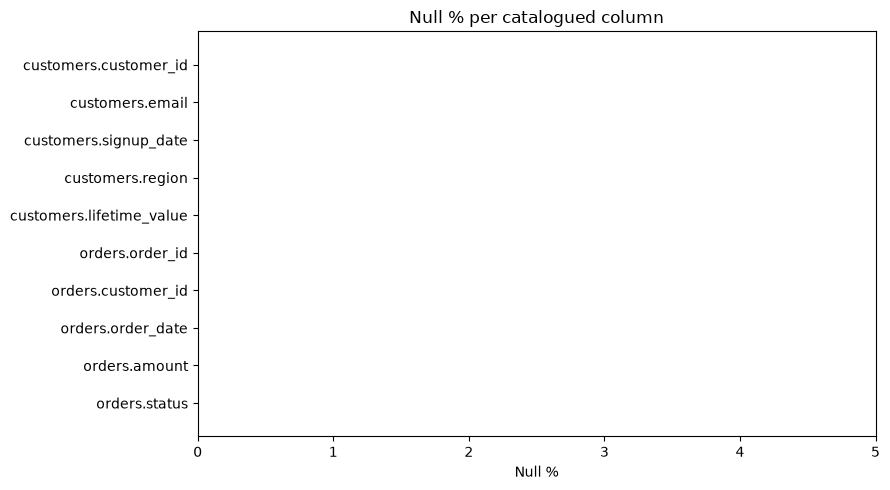

saved null_pct_per_column.png


In [8]:
rows = []
for e in cat.entries.values():
    for c in e.columns:
        rows.append((f'{e.name}.{c.name}', c.null_pct))
labels = [r[0] for r in rows]
nulls = [r[1] for r in rows]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(labels, nulls, color='#3b82f6')
ax.set_xlabel('Null %')
ax.set_title('Null % per catalogued column')
ax.set_xlim(0, max(5, max(nulls) * 1.2 if nulls else 5))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('null_pct_per_column.png', dpi=150)
plt.show()
print('saved null_pct_per_column.png')

<a id='export'></a>
## 8. Markdown export

The catalog exports as a Markdown data dictionary - paste it into a wiki so
the knowledge outlives any one person's memory.

In [9]:
md_text = cat.to_markdown()
print(md_text[:900])

# Data Catalog

_2 tables catalogued._

## customers
- **Owner:** growth-team
- **Description:** One row per registered customer with contact + value.
- **Tags:** crm, pii, core
- **Shape:** 50 rows x 5 columns

| Column | Type | Semantic | Null % | Distinct | Samples |
|---|---|---|---|---|---|
| customer_id | object | id | 0.0% | 50 | C1000, C1001, C1002 |
| email | object | email | 0.0% | 50 | user0@shop.com, user1@shop.com, user2@shop.com |
| signup_date | datetime64[ns] | date | 0.0% | 49 | 2025-01-12 00:00:00, 2024-09-07 00:00:00, 2024-09-30 00:00:00 |
| region | object | category | 0.0% | 4 | North, East, West |
| lifetime_value | float64 | numeric | 0.0% | 50 | 800.06, 614.34, 320.11 |

## orders
- **Owner:** commerce-team
- **Description:** One row per order placed, linked to customers by customer_id.
- **Tags:** transactions, core
- **Shape:** 200 rows x 5 columns

| Column | T


<a id='summary'></a>
## 9. Summary

- **Auto-profiled** 2 tables into catalog entries: shape + per-column dtype,
  null %, distinct count, sample values, and an inferred semantic type.
- **Enriched** each with human metadata (owner / description / tags) that no
  profiler can guess.
- **Searched** across names, columns, descriptions, and tags in one box.
- **Exported** a Markdown data dictionary for the team wiki.

The semantic types are heuristic **guesses** - a human confirms them. The
catalog is for discovery and documentation, not access control.

<a id='byo'></a>
## 10. Try your own data

In [10]:
# Point the catalog at your own CSVs - uncomment and edit:
#
# my_df = pd.read_csv('your_table.csv')
# cat.add(profile_dataframe(
#     my_df, 'your_table', owner='you@team',
#     description='what this table is', tags=['your', 'tags'],
# ))
# display(pd.DataFrame([vars(c) for c in cat.entries['your_table'].columns]))
# print(cat.to_markdown())

---
Built by Phoebe Fu - [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) - Day 93: Lightweight Data Catalog.